# Stitched waterfall: the 29_n15 `Optimal` **three-segment** scan (7-27-26)

This is [`waterfall_stitched_29_n15.ipynb`](waterfall_stitched_29_n15.ipynb) generalised from
**two** segments to **N**, applied to the 7/27 acquisition that covers the full range in
**three overlapping segments**:

`data/focusing_images/7-27-26/29_n15/Optimal/`

| segment | folder | frames | `positions.csv` | nominal global start |
|---|---|---|---|---|
| 1 | `0mm-25mm/l=<n>/`  | 51 | 0.0 → 25.0 mm | 0 mm |
| 2 | `20mm-45mm/l=<n>/` | 51 | 0.0 → 25.0 mm | 20 mm |
| 3 | `40mm-65mm/l=<n>/` | 51 | 0.0 → 25.0 mm | 40 mm |

**Every** segment's `positions.csv` is *local* — each one restarts at 0.0 — so a segment's true
global $z$ is `local_z + offset`, and the folder name only gives the nominal offset. Nominally
the segments overlap by 5 mm each, giving a combined span of ~0 → 65 mm.

**Offsets are set by hand, per segment, per $\ell$** — same philosophy as the two-segment
notebook. Each segment after the first is placed by matching its beam-width curve onto the
*already-placed* chain, and offsets are **absolute global starts** (not increments), so tuning
segment 2 does not drag segment 3 around with it.

**What this notebook does, per topological charge $\ell$:**

1. Process all three segments independently with the base pipeline (centroid tracking →
   transverse slice → per-segment waterfall) on each segment's *local* $z$, plus a per-frame
   beam-width trace.
2. Place segment $k$ at `local_z + STARTS_MM[ell][seg]`.
3. **Stitch** by resampling every segment onto one common global-$z$ grid (linear interpolation
   in $z$, honouring sub-frame offsets), then blending with per-segment weights — *crossfade*,
   *average*, or *hardcut* — which now handles **two seams** (and any point where three
   segments might overlap) in one pass.
4. Draw the stitched waterfalls, the stitched width curves, a centroid diagnostic, and a
   summary table.

Outputs go under `outputs/waterfalls_stitched_3seg/`.

> **Data note.** In `0mm-25mm/l=0/` the TIFFs are named `29_n15_l5_*.tif` — a stale filename
> prefix from acquisition. The images are *not* copies of the `l=5` set (checked by hash), so
> the folder name is authoritative and the loader keys off the folder, not the filename.

In [1]:
from __future__ import annotations

import re
from dataclasses import dataclass, field
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image


def find_repo_root(start: Path | None = None) -> Path:
    """Walk up to the directory holding pyproject.toml (see the base notebook)."""
    here = (start or Path.cwd()).resolve()
    for candidate in (here, *here.parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError(f"no pyproject.toml at or above {here}")


REPO_ROOT = find_repo_root()
DATA_ROOT = REPO_ROOT / "data" / "focusing_images"
OPTIMAL_ROOT = DATA_ROOT / "7-27-26" / "29_n15" / "Optimal"
OUT_ROOT = REPO_ROOT / "outputs" / "waterfalls_stitched_3seg"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

print(f"repo root    : {REPO_ROOT}")
print(f"Optimal root : {OPTIMAL_ROOT}")
print(f"figures      : {OUT_ROOT}")
assert OPTIMAL_ROOT.is_dir(), f"missing {OPTIMAL_ROOT}"

repo root    : /home/lukas/Documents/PhD/0_Projects/06_OAM_Focusing/carrie_work/Optimal_Focusing
Optimal root : /home/lukas/Documents/PhD/0_Projects/06_OAM_Focusing/carrie_work/Optimal_Focusing/data/focusing_images/7-27-26/29_n15/Optimal
figures      : /home/lukas/Documents/PhD/0_Projects/06_OAM_Focusing/carrie_work/Optimal_Focusing/outputs/waterfalls_stitched_3seg


## Tunables

`SEGMENTS` is now an **ordered** mapping — add or remove entries here and the whole notebook
follows; nothing below hard-codes "two" or "three". The order defines the chain: each segment
is aligned against the ones already placed to its left.

The slicing / centroid knobs are copied verbatim from the base notebook so the analyses stay
directly comparable.

In [2]:
RUN_LABEL = "29_n15_Optimal_7-27-26"

# Ordered: segment label -> folder + nominal global start (mm), taken from the folder name.
SEGMENTS = {
    "0-25":  {"dir": OPTIMAL_ROOT / "0mm-25mm",  "nominal_start_mm":  0.0},
    "20-45": {"dir": OPTIMAL_ROOT / "20mm-45mm", "nominal_start_mm": 20.0},
    "40-65": {"dir": OPTIMAL_ROOT / "40mm-65mm", "nominal_start_mm": 40.0},
}
SEG_LABELS = list(SEGMENTS)          # chain order
SEG_REF = SEG_LABELS[0]              # reference segment: defines global z = local z

ELLS = [0, 1, 2, 3, 4, 5]            # charges present in every segment

STEP_MM = 0.5                        # stage step; also the fallback if a positions.csv is odd

# --- slicing (verbatim from waterfall_plot.ipynb) -------------------------
SLICE_AXIS = "x"
N_LINES_AVG = 1
TRACK_CENTRE_PER_FRAME = True
CENTER_TRANSVERSE = True
CROP_HALF_WIDTH = 200

# --- centroid finding (verbatim) ------------------------------------------
BG_BORDER = 50
THRESH_FRAC = 0.10
WINDOW_RADIUS = 200
# --------------------------------------------------------------------------

if SLICE_AXIS not in ("x", "y"):
    raise ValueError(f"SLICE_AXIS must be 'x' or 'y', got {SLICE_AXIS!r}")

for label, info in SEGMENTS.items():
    assert info["dir"].is_dir(), f"missing segment folder {info['dir']}"
    for ell in ELLS:
        assert (info["dir"] / f"l={ell}").is_dir(), f"missing {info['dir'].name}/l={ell}"

print(f"slicing along {SLICE_AXIS}")
print(f"{len(SEGMENTS)} segments in chain order: {' -> '.join(SEG_LABELS)}")
print(f"reference segment (global z == local z): {SEG_REF}")


# --- Centroid tracking mode -------------------------------------------------
# "per_frame": locate the beam centroid independently in every frame (default).
# "line":      replace it with a straight line centroid(z) = slope*z + offset,
#              fit with its OWN slope and offset PER SECTION (segment/scan) --
#              nothing is shared across sections.  See centroid_lines.py.
CENTROID_MODE = "per_frame"


slicing along x
3 segments in chain order: 0-25 -> 20-45 -> 40-65
reference segment (global z == local z): 0-25


## Frame loading, background, centroid — unchanged from the base notebook

Identical helpers: frames ordered by the trailing `_NNNN` index, loaded as `float32`;
background = median of a border strip; centroid = background-subtracted, thresholded intensity
centroid refined within a window. A `Segment` here is one `l=<n>` folder of one of the three
segments.

In [3]:
INDEX_RE = re.compile(r"_(\d+)\.tif$", re.IGNORECASE)


@dataclass(frozen=True)
class Segment:
    """One `l=<n>` folder within one segment of the scan."""

    seg: str          # "0-25" | "20-45" | "40-65"
    ell: int
    directory: Path
    nominal_start_mm: float


def frame_index(path: Path) -> int:
    m = INDEX_RE.search(path.name)
    if m is None:
        raise ValueError(f"cannot parse a frame index from {path.name}")
    return int(m.group(1))


def frame_paths(directory: Path) -> list[Path]:
    tifs = [p for p in directory.glob("*.tif") if not p.name.startswith(".")]
    return sorted(tifs, key=frame_index)


def load_local_positions(directory: Path, paths: list[Path]) -> np.ndarray:
    """Local z (mm) from positions.csv, falling back to index*STEP_MM if it is unusable."""
    csv = directory / "positions.csv"
    if csv.is_file():
        table = pd.read_csv(csv)
        by_name = dict(zip(table["image"], table["position_mm"]))
        if all(p.name in by_name for p in paths):
            return np.array([float(by_name[p.name]) for p in paths])
        print(f"  ! {directory.parent.name}/{directory.name}: positions.csv does not name every "
              f"frame — inferring local z = index * {STEP_MM} mm")
    else:
        print(f"  ! {directory.parent.name}/{directory.name}: no positions.csv — "
              f"inferring local z = index * {STEP_MM} mm")
    return np.array([frame_index(p) * STEP_MM for p in paths])


def load_frames(paths: list[Path]) -> np.ndarray:
    first = np.asarray(Image.open(paths[0]), dtype=np.float32)
    frames = np.empty((len(paths), *first.shape), dtype=np.float32)
    frames[0] = first
    for i, path in enumerate(paths[1:], start=1):
        frame = np.asarray(Image.open(path), dtype=np.float32)
        if frame.shape != first.shape:
            raise ValueError(f"{path.name} is {frame.shape}, expected {first.shape}")
        frames[i] = frame
    return frames


def background_level(frame: np.ndarray, border: int = BG_BORDER) -> float:
    edges = np.concatenate([
        frame[:border, :].ravel(), frame[-border:, :].ravel(),
        frame[:, :border].ravel(), frame[:, -border:].ravel(),
    ])
    return float(np.median(edges))


def _centroid(weights: np.ndarray) -> tuple[float, float]:
    total = weights.sum()
    if total <= 0:
        raise ValueError("no signal above threshold")
    rows = np.arange(weights.shape[0])[:, None]
    cols = np.arange(weights.shape[1])[None, :]
    return float((weights * rows).sum() / total), float((weights * cols).sum() / total)


def find_centroid(frame: np.ndarray) -> tuple[float, float, float]:
    signal = np.clip(frame - background_level(frame), 0, None)
    weights = np.where(signal >= THRESH_FRAC * signal.max(), signal, 0.0)
    cy, cx = _centroid(weights)
    if WINDOW_RADIUS is not None:
        r0 = max(int(round(cy)) - WINDOW_RADIUS, 0)
        c0 = max(int(round(cx)) - WINDOW_RADIUS, 0)
        window = weights[r0:r0 + 2 * WINDOW_RADIUS, c0:c0 + 2 * WINDOW_RADIUS]
        dy, dx = _centroid(window)
        cy, cx = r0 + dy, c0 + dx
    # brightness weight: bright, well-defined in-focus frames dominate the line fit
    return cy, cx, float(signal.max())

## Process one segment into a waterfall + a registration feature

`process_segment` is the base notebook's `process_dataset`, extended to also return a per-frame
**beam-width** trace used for alignment: the intensity-weighted transverse **RMS radius** about
the centre of each already-centred, background-subtracted slice.

In [4]:
@dataclass
class SegWaterfall:
    """One segment of one ell: its waterfall on *local* z, plus registration features."""

    seg: str
    ell: int
    nominal_start_mm: float
    waterfall: np.ndarray     # (n_z, n_s), NOT yet peak-normalised (raw, bg-subtracted)
    s_px: np.ndarray          # (n_s,) transverse coord about the centre
    z_local: np.ndarray       # (n_z,) local z (mm)
    centroid_y: np.ndarray          # FITTED straight-line centroid actually used
    centroid_x: np.ndarray
    centroid_y_raw: np.ndarray      # raw per-frame centroid, kept for diagnostics
    centroid_x_raw: np.ndarray
    centroid_w: np.ndarray          # per-frame brightness weight used in the fit
    width_px: np.ndarray      # (n_z,) transverse RMS radius per frame
    onaxis: np.ndarray        # (n_z,) central-column intensity per frame


def _rms_width(profile: np.ndarray, s_px: np.ndarray) -> float:
    w = np.clip(profile, 0, None)
    total = w.sum()
    if total <= 0:
        return np.nan
    mean = (w * s_px).sum() / total
    return float(np.sqrt((w * (s_px - mean) ** 2).sum() / total))


def segment_raw_centroids(segment: Segment):
    """Pass 1: load a segment's frames and return (z_local, centroid_y,
    centroid_x, weight) -- the RAW per-frame centroid and brightness, before the
    shared straight-line fit."""
    paths = frame_paths(segment.directory)
    if not paths:
        raise FileNotFoundError(f"no TIFFs in {segment.directory}")
    z_local = load_local_positions(segment.directory, paths)
    frames = load_frames(paths)
    cen = np.array([find_centroid(f) for f in frames])   # (n, 3): row, col, brightness
    return z_local, cen[:, 0], cen[:, 1], cen[:, 2]


def process_segment(segment: Segment, centroid_y: np.ndarray, centroid_x: np.ndarray,
                    centroid_y_raw: np.ndarray, centroid_x_raw: np.ndarray,
                    centroid_w: np.ndarray) -> SegWaterfall:
    """Pass 2: build one segment's waterfall on the supplied FITTED straight-line
    centroid (no per-frame wobble).  Frames are reloaded here (released after the
    raw-centroid pass) so peak memory stays at a single segment."""
    paths = frame_paths(segment.directory)
    z_local = load_local_positions(segment.directory, paths)
    frames = load_frames(paths)

    if SLICE_AXIS == "x":
        cuts, centre_along, centre_across = frames, centroid_y, centroid_x
    else:
        cuts, centre_along, centre_across = frames.transpose(0, 2, 1), centroid_x, centroid_y
    n_lines, length = cuts.shape[1], cuts.shape[2]

    half = N_LINES_AVG // 2
    fixed_line = int(round(centre_along.mean()))
    background = float(np.median([background_level(f) for f in frames]))

    slices = []
    for plane, c_along, c_across in zip(cuts, centre_along, centre_across):
        line = int(round(c_along)) if TRACK_CENTRE_PER_FRAME else fixed_line
        lo = int(np.clip(line - half, 0, n_lines - N_LINES_AVG))
        cut = plane[lo:lo + N_LINES_AVG].mean(axis=0)
        if CENTER_TRANSVERSE:
            cut = np.roll(cut, length // 2 - int(round(c_across)))
        slices.append(cut)

    waterfall = np.clip(np.stack(slices) - background, 0, None)  # raw, not peak-normalised
    del cuts, frames

    s_px = np.arange(length) - (length // 2 if CENTER_TRANSVERSE else 0)
    if CROP_HALF_WIDTH is not None:
        keep = np.abs(s_px) <= CROP_HALF_WIDTH
        waterfall, s_px = waterfall[:, keep], s_px[keep]

    width_px = np.array([_rms_width(row, s_px) for row in waterfall])
    centre_idx = int(np.argmin(np.abs(s_px)))
    onaxis = waterfall[:, centre_idx].astype(float)

    return SegWaterfall(
        seg=segment.seg, ell=segment.ell, nominal_start_mm=segment.nominal_start_mm,
        waterfall=waterfall, s_px=s_px, z_local=z_local,
        centroid_y=centroid_y, centroid_x=centroid_x,
        centroid_y_raw=centroid_y_raw, centroid_x_raw=centroid_x_raw, centroid_w=centroid_w,
        width_px=width_px, onaxis=onaxis,
    )

## Process every segment, for every $\ell$

18 folders (3 segments × 6 charges) × 51 frames — this is the slow cell, a couple of minutes.

In [5]:
# Centroid tracking is set by CENTROID_MODE (see config):
#   "per_frame" (default): the raw per-frame centroid is used directly.
#   "line": a straight line centroid(z)=slope*z+offset is fit with its OWN
#           slope+offset PER SEGMENT and each segment is built on it.
#   pass 1: raw per-frame centroid + brightness for every (ell, segment)
#   pass 2: rebuild each segment (frames reloaded, so peak memory stays at one
#           segment) on the raw centroid or, in "line" mode, its fitted line.
from centroid_lines import fit_centroid_lines

raw_sections: dict[tuple[int, str], dict] = {}
segment_objs: dict[tuple[int, str], Segment] = {}
for ell in ELLS:
    for seg_label, info in SEGMENTS.items():
        directory = info["dir"] / f"l={ell}"
        segment = Segment(seg_label, ell, directory, info["nominal_start_mm"])
        z_local, cy, cx, w = segment_raw_centroids(segment)
        raw_sections[(ell, seg_label)] = dict(z=z_local, cy=cy, cx=cx, w=w)
        segment_objs[(ell, seg_label)] = segment

# per_frame (default): build on the raw per-frame centroid.  line: build on a
# per-section straight-line fit (own slope+offset for each segment).
lines = (fit_centroid_lines(raw_sections, shared_slope=False)[0]
         if CENTROID_MODE == "line" else None)
print(f"centroid mode = {CENTROID_MODE}\n")

segments: dict[int, dict[str, SegWaterfall]] = {ell: {} for ell in ELLS}
for (ell, seg_label), segment in segment_objs.items():
    r = raw_sections[(ell, seg_label)]
    cy_use, cx_use = lines[(ell, seg_label)] if CENTROID_MODE == "line" else (r["cy"], r["cx"])
    sw = process_segment(segment, cy_use, cx_use, r["cy"], r["cx"], r["w"])
    segments[ell][seg_label] = sw
    print(f"{seg_label:>6}  l={ell}  {str(sw.waterfall.shape):>12}  "
          f"local z {sw.z_local.min():.1f}..{sw.z_local.max():.1f} mm")
print(f"\nall {len(SEGMENTS)} segments processed for every ell")


centroid mode = per_frame



  0-25  l=0     (51, 401)  local z 0.0..25.0 mm


 20-45  l=0     (51, 401)  local z 0.0..25.0 mm


 40-65  l=0     (51, 401)  local z 0.0..25.0 mm


  0-25  l=1     (51, 401)  local z 0.0..25.0 mm


...

 20-45  l=4     (51, 401)  local z 0.0..25.0 mm


 40-65  l=4     (51, 401)  local z 0.0..25.0 mm


  0-25  l=5     (51, 401)  local z 0.0..25.0 mm


 20-45  l=5     (51, 401)  local z 0.0..25.0 mm


 40-65  l=5     (51, 401)  local z 0.0..25.0 mm

all 3 segments processed for every ell


## Set each segment's global start, per $\ell$ (edit `STARTS_MM` by hand)

Segment $k$'s global $z$ is `local_z + STARTS_MM[ell][seg]`. These are **absolute** global
starts, so each segment is tuned independently — nudging segment 2 will not move segment 3.

The reference segment is pinned at 0 by definition. For the others, pick the value that lands
that segment's width curve on the curve of the segment before it, over their shared band. The
next cell plots exactly that, so this is a look-and-nudge loop:

* too **small** → the segment sits to the left, its curve rides **above** its predecessor's;
* too **large** → it sits to the right, its curve drops **below**;
* just right → the curves lie on top of each other across the overlap.

Defaults seed segment 2 at the value that worked for the earlier two-segment dataset (23 mm,
i.e. 3 mm past nominal) and carry the same nominal-to-true correction to segment 3 (43 mm).
**Re-tune both against the diagnostic below — this is different data.** $\ell=0$ is a Gaussian
(its width behaves differently and has no sharp match), so its values just follow the donut
consensus.

In [6]:
# Absolute global start of each segment (mm), per ell. EDIT THESE BY HAND.
# The reference segment is pinned at 0.0. The next cell overlays each choice on the width curves.
DEFAULT_STARTS = {"0-25": 0.0, "20-45": 23.0, "40-65": 43.0}

STARTS_MM: dict[int, dict[str, float]] = {
    0: {"0-25": 0.0, "20-45": 24.0, "40-65": 44.5},   # Gaussian: follows the donut consensus
    1: {"0-25": 0.0, "20-45": 24.0, "40-65": 44.5},
    2: {"0-25": 0.0, "20-45": 24.0, "40-65": 43.5},
    3: {"0-25": 0.0, "20-45": 24.0, "40-65": 44.5},
    4: {"0-25": 0.0, "20-45": 24.0, "40-65": 44.5},
    5: {"0-25": 0.0, "20-45": 24.5, "40-65": 45.0},
}

assert set(STARTS_MM) == set(ELLS), "STARTS_MM must have exactly one entry per ell in ELLS"
for ell in ELLS:
    assert set(STARTS_MM[ell]) == set(SEG_LABELS), \
        f"STARTS_MM[{ell}] must name every segment in SEGMENTS"
    assert STARTS_MM[ell][SEG_REF] == 0.0, \
        f"the reference segment {SEG_REF!r} must stay pinned at 0.0"

NOMINAL_STARTS = {lbl: SEGMENTS[lbl]["nominal_start_mm"] for lbl in SEG_LABELS}


def global_z(sw: SegWaterfall, ell: int) -> np.ndarray:
    """A segment's frames on the global z axis, given the hand-set starts."""
    return sw.z_local + STARTS_MM[ell][sw.seg]


for ell in ELLS:
    parts = [f"{lbl} @ {STARTS_MM[ell][lbl]:6.2f} (nom {NOMINAL_STARTS[lbl]:.0f})"
             for lbl in SEG_LABELS]
    print(f"  l={ell}: " + " | ".join(parts))

  l=0: 0-25 @   0.00 (nom 0) | 20-45 @  24.00 (nom 20) | 40-65 @  44.50 (nom 40)
  l=1: 0-25 @   0.00 (nom 0) | 20-45 @  24.00 (nom 20) | 40-65 @  44.50 (nom 40)
  l=2: 0-25 @   0.00 (nom 0) | 20-45 @  24.00 (nom 20) | 40-65 @  43.50 (nom 40)
  l=3: 0-25 @   0.00 (nom 0) | 20-45 @  24.00 (nom 20) | 40-65 @  44.50 (nom 40)
  l=4: 0-25 @   0.00 (nom 0) | 20-45 @  24.00 (nom 20) | 40-65 @  44.50 (nom 40)
  l=5: 0-25 @   0.00 (nom 0) | 20-45 @  24.50 (nom 20) | 40-65 @  45.00 (nom 40)


### Check the offsets: do the width curves line up?

One panel per $\ell$: every segment's beam-width trace on global $z$ at your hand-set start
(solid, coloured), plus — faint grey — each non-reference segment at its **nominal** start for
reference. Vertical dashed lines mark the seams. A good set of starts has neighbouring curves
lying on top of each other through each shared band.

No searching happens here — this only *shows* the starts you set, so what you see is exactly
what gets stitched.

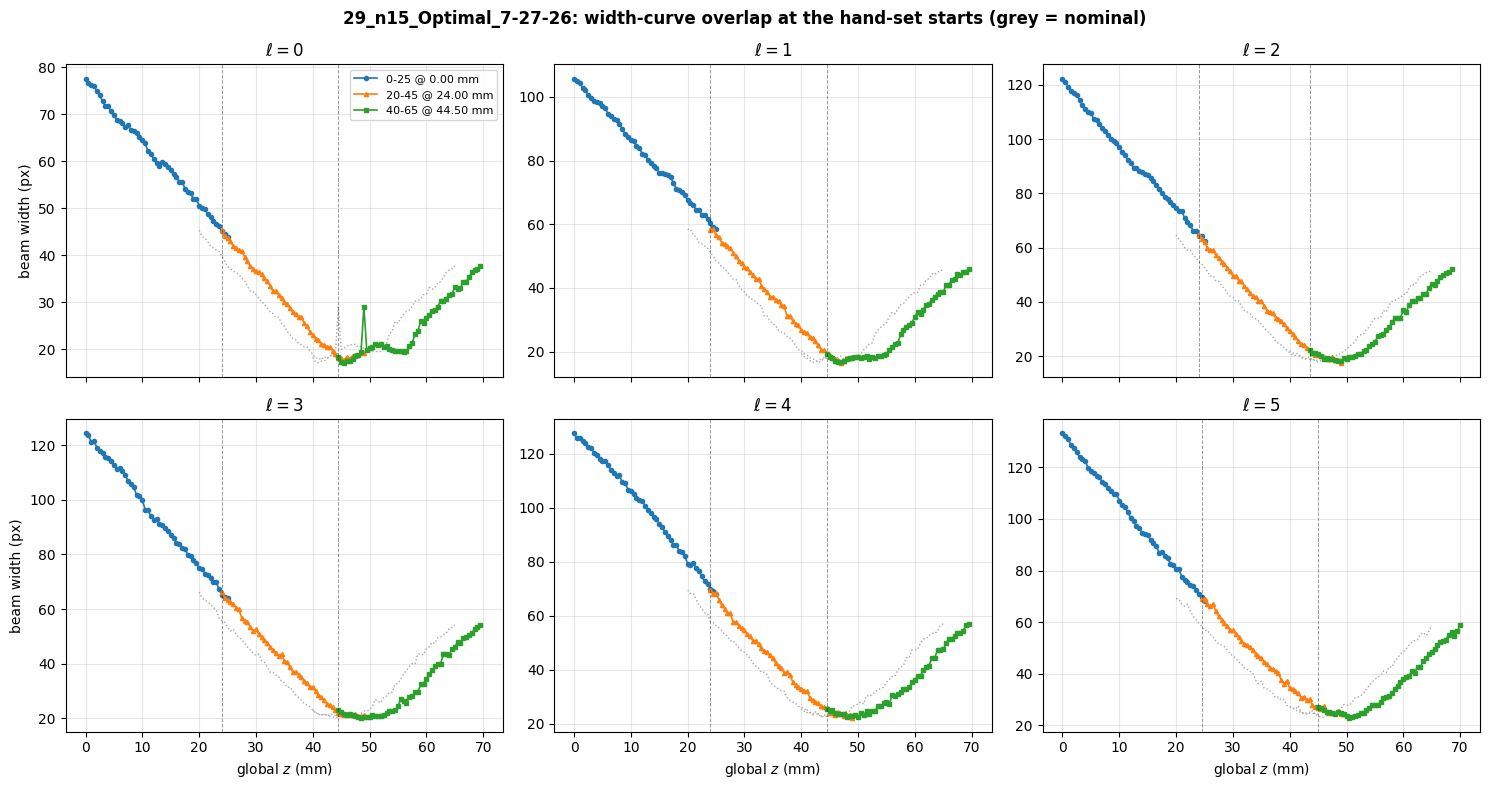

In [7]:
SEG_COLOURS = {lbl: f"C{i}" for i, lbl in enumerate(SEG_LABELS)}
SEG_MARKERS = {lbl: m for lbl, m in zip(SEG_LABELS, ["o-", "^-", "s-", "d-", "v-"])}

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)

for ell, ax in zip(ELLS, axes.ravel()):
    for lbl in SEG_LABELS:
        sw = segments[ell][lbl]
        if lbl != SEG_REF:   # nominal placement, for reference
            ax.plot(sw.z_local + NOMINAL_STARTS[lbl], sw.width_px, ":", ms=2.5, lw=1,
                    color="0.65", zorder=1)
        ax.plot(global_z(sw, ell), sw.width_px, SEG_MARKERS[lbl], ms=3, lw=1.2,
                color=SEG_COLOURS[lbl], zorder=2,
                label=f"{lbl} @ {STARTS_MM[ell][lbl]:.2f} mm")

    # seams: where each segment starts (except the reference)
    for lbl in SEG_LABELS[1:]:
        ax.axvline(STARTS_MM[ell][lbl], color="k", ls="--", lw=0.7, alpha=0.4)

    ax.set_title(f"$\\ell={ell}$")
    ax.grid(alpha=0.3)

axes[0, 0].legend(fontsize=8, loc="upper right")
axes[0, 0].plot([], [], ":", color="0.65", label="nominal")   # legend hint
for ax in axes[:, 0]:
    ax.set_ylabel("beam width (px)")
for ax in axes[-1, :]:
    ax.set_xlabel("global $z$ (mm)")
fig.suptitle(f"{RUN_LABEL}: width-curve overlap at the hand-set starts (grey = nominal)",
             fontweight="bold")
fig.tight_layout()
fig.savefig(OUT_ROOT / "alignment_diagnostic.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

### Zoom on each seam

The panels above show the whole 0 → 65 mm span, which makes a sub-mm misplacement hard to
judge. This figure zooms each seam (one column per seam, one row per $\ell$) to just the shared
band plus a small margin, showing only the two segments that meet there. Nudge
`STARTS_MM` until the two curves sit on each other in every panel of a column.

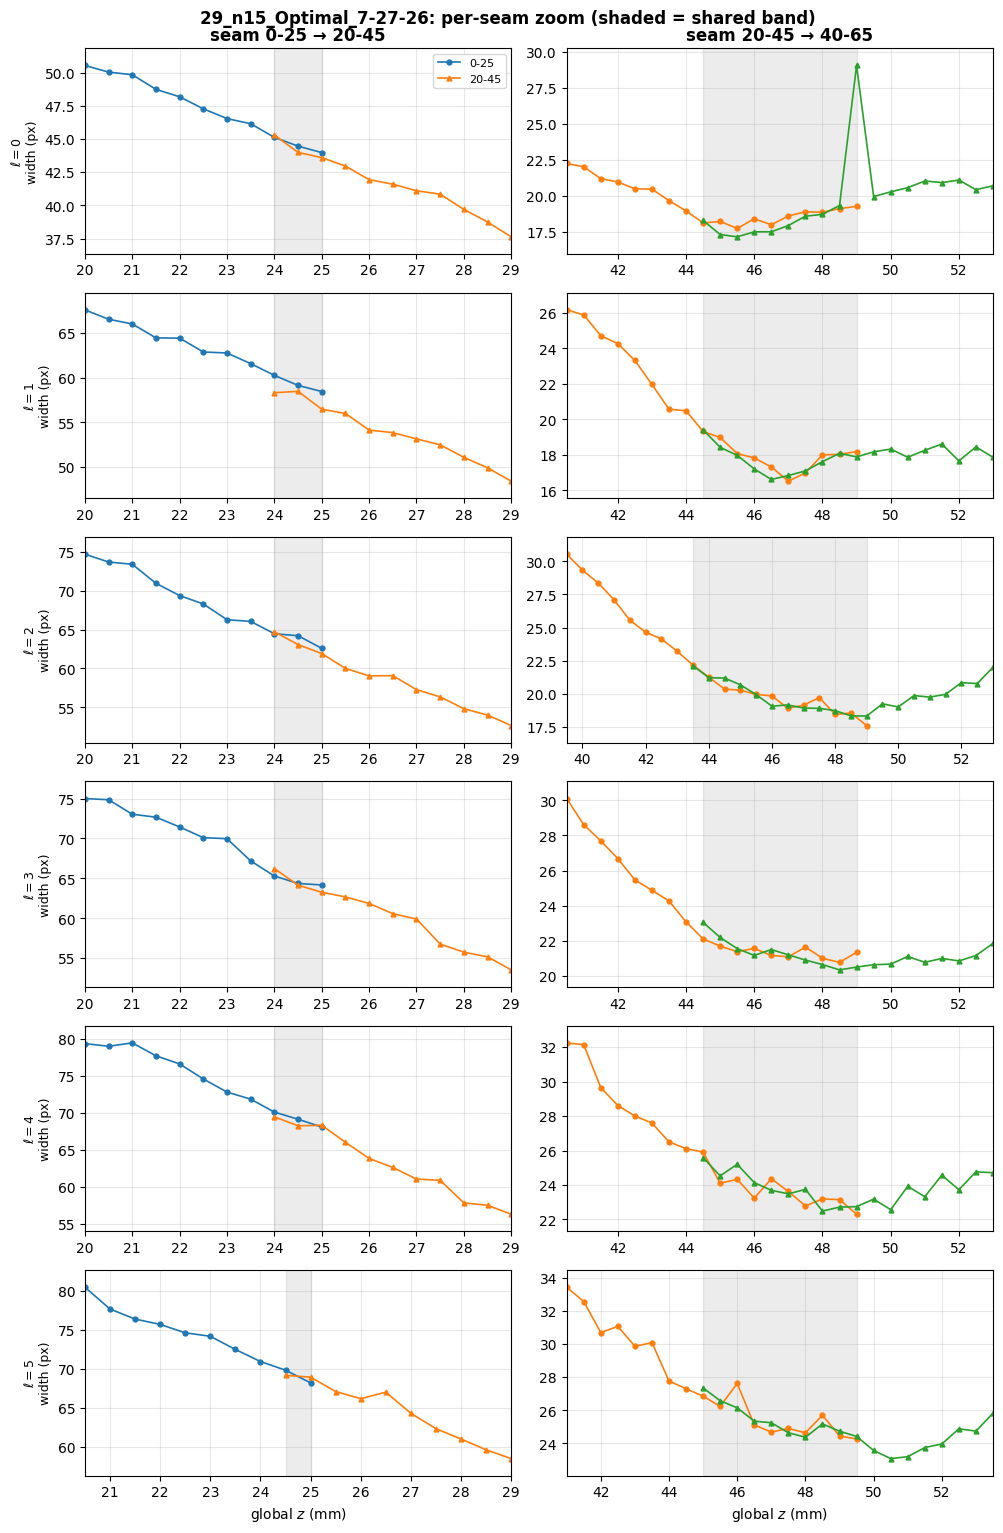

In [8]:
SEAMS = list(zip(SEG_LABELS[:-1], SEG_LABELS[1:]))   # consecutive pairs

fig, axes = plt.subplots(len(ELLS), len(SEAMS),
                         figsize=(5.0 * len(SEAMS), 2.6 * len(ELLS)), squeeze=False)

for r, ell in enumerate(ELLS):
    for c, (left, right) in enumerate(SEAMS):
        ax = axes[r, c]
        zl, zr = global_z(segments[ell][left], ell), global_z(segments[ell][right], ell)
        ax.plot(zl, segments[ell][left].width_px, "o-", ms=3.5, lw=1.2,
                color=SEG_COLOURS[left], label=left)
        ax.plot(zr, segments[ell][right].width_px, "^-", ms=3.5, lw=1.2,
                color=SEG_COLOURS[right], label=right)

        lo, hi = max(zl[0], zr[0]), min(zl[-1], zr[-1])       # shared band
        if hi > lo:
            ax.axvspan(lo, hi, color="grey", alpha=0.15)
            ax.set_xlim(lo - 4, hi + 4)
        else:
            ax.set_xlim(min(zl[-1], zr[0]) - 4, max(zl[-1], zr[0]) + 4)
            ax.text(0.5, 0.9, "no overlap!", transform=ax.transAxes, ha="center",
                    color="crimson", fontweight="bold")

        band = np.concatenate([
            segments[ell][left].width_px[(zl >= lo - 4) & (zl <= hi + 4)],
            segments[ell][right].width_px[(zr >= lo - 4) & (zr <= hi + 4)],
        ])
        band = band[np.isfinite(band)]
        if band.size:
            pad = 0.1 * (band.max() - band.min() + 1e-9)
            ax.set_ylim(band.min() - pad, band.max() + pad)

        ax.grid(alpha=0.3)
        if r == 0:
            ax.set_title(f"seam {left} → {right}", fontweight="bold")
        if r == 0 and c == 0:
            ax.legend(fontsize=8)
        if c == 0:
            ax.set_ylabel(f"$\\ell={ell}$\nwidth (px)", fontsize=9)
        if r == len(ELLS) - 1:
            ax.set_xlabel("global $z$ (mm)")

fig.suptitle(f"{RUN_LABEL}: per-seam zoom (shaded = shared band)", fontweight="bold")
fig.tight_layout()
fig.savefig(OUT_ROOT / "seam_zoom.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

## Stitch all segments onto one global-$z$ grid

The starts are **sub-frame** values (e.g. 23.0 or 22.75 mm, not necessarily a whole number of
0.5 mm steps), so segments do not share a sample grid. We build one uniform global grid at
`STEP_MM` spanning the full union of the placed segments and **resample every segment onto it
by linear interpolation in $z$**, column by column, so each segment lands at its true global
$z$ to sub-frame precision.

Blending generalises from the two-segment case to a **per-segment weight map** $w_k(z)$,
normalised so $\sum_k w_k = 1$ wherever anything is covered:

* **crossfade** — inside a two-segment overlap, a linear ramp handing over from the earlier
  segment to the later one; the ramp runs over that specific overlap band, so both seams fade
  independently.
* **average** — equal weight to every segment covering that $z$.
* **hardcut** — the earlier segment wins up to the overlap midpoint, the later one after; with
  more than two segments this is applied over the whole chain, so each row is taken from
  exactly one segment.

Each blended map is peak-normalised **after** stitching, so colours are comparable across the
whole 0 → ~65 mm scan.

In [9]:
BLEND_MODES = ["crossfade", "average", "hardcut"]


@dataclass
class Stitched:
    ell: int
    mode: str
    waterfall: np.ndarray   # (n_z, n_s) peak-normalised, on the common global grid
    s_px: np.ndarray
    z_mm: np.ndarray        # (n_z,) uniform global z
    centroid_y: np.ndarray  # on the common grid (for diagnostics)
    centroid_x: np.ndarray
    coverage: np.ndarray    # (n_z,) how many segments cover each row

    @property
    def brightest_z(self) -> float:
        return float(self.z_mm[self.waterfall.max(axis=1).argmax()])


def _resample_map(z_src: np.ndarray, water_src: np.ndarray, z_grid: np.ndarray):
    """Linear-interpolate a (n_z, n_s) map from z_src onto z_grid, per transverse column.

    Returns (resampled_map, covered_mask): rows of z_grid outside z_src are 0 and masked out.
    """
    covered = (z_grid >= z_src[0] - 1e-9) & (z_grid <= z_src[-1] + 1e-9)
    out = np.zeros((len(z_grid), water_src.shape[1]))
    if covered.any():
        zc = z_grid[covered]
        out[covered] = np.stack(
            [np.interp(zc, z_src, water_src[:, c]) for c in range(water_src.shape[1])], axis=1
        )
    return out, covered


def _blend_weights(mode: str, z_grid: np.ndarray, covers: dict[str, np.ndarray],
                   zspans: dict[str, tuple[float, float]]) -> dict[str, np.ndarray]:
    """Per-segment weight along z. Normalised to sum to 1 wherever anything is covered.

    `covers[lbl]` is the boolean coverage mask of segment `lbl` on `z_grid`;
    `zspans[lbl]` is its (start, end) in global z.
    """
    order = [lbl for lbl in SEG_LABELS if lbl in covers]
    w = {lbl: covers[lbl].astype(float) for lbl in order}   # start from plain coverage

    if mode == "average":
        pass                                                # equal weight where covered

    elif mode == "hardcut":
        # earlier segment owns rows up to the midpoint of each pairwise overlap
        for left, right in zip(order[:-1], order[1:]):
            both = covers[left] & covers[right]
            if not both.any():
                continue
            z_ov = z_grid[both]
            mid = 0.5 * (z_ov.min() + z_ov.max())
            w[left][both] = np.where(z_ov <= mid, 1.0, 0.0)
            w[right][both] = np.where(z_ov <= mid, 0.0, 1.0)

    else:  # crossfade: linear hand-over across each pairwise overlap band
        for left, right in zip(order[:-1], order[1:]):
            both = covers[left] & covers[right]
            if not both.any():
                continue
            z_ov = z_grid[both]
            lo, hi = z_ov.min(), z_ov.max()
            ramp = np.clip((hi - z_ov) / (hi - lo), 0.0, 1.0) if hi > lo else np.full(z_ov.shape, 0.5)
            w[left][both] = ramp
            w[right][both] = 1.0 - ramp

    stack = np.stack([w[lbl] for lbl in order])             # (n_seg, n_z)
    total = stack.sum(axis=0)
    good = total > 0
    stack[:, good] /= total[good]
    return {lbl: stack[i] for i, lbl in enumerate(order)}


def stitch(ell: int, mode: str, z_grid: np.ndarray) -> Stitched:
    sws = {lbl: segments[ell][lbl] for lbl in SEG_LABELS}
    s_px = sws[SEG_REF].s_px
    for lbl, sw in sws.items():
        assert np.array_equal(sw.s_px, s_px), f"segment {lbl} cropped to a different extent"

    maps, covers, zspans, zs = {}, {}, {}, {}
    for lbl, sw in sws.items():
        z = global_z(sw, ell)
        m, cov = _resample_map(z, sw.waterfall, z_grid)
        maps[lbl], covers[lbl], zspans[lbl], zs[lbl] = m, cov, (z[0], z[-1]), z

    weights = _blend_weights(mode, z_grid, covers, zspans)

    water = np.zeros_like(maps[SEG_REF])
    for lbl in SEG_LABELS:
        water += weights[lbl][:, None] * maps[lbl]

    covered_any = np.any([covers[lbl] for lbl in SEG_LABELS], axis=0)
    water[~covered_any] = 0.0

    peak = float(water.max())
    if peak > 0:
        water /= peak

    # centroids on the common grid: take the first segment in chain order that covers each row
    cy = np.full(z_grid.shape, np.nan)
    cx = np.full(z_grid.shape, np.nan)
    for lbl in SEG_LABELS:
        need = np.isnan(cy) & covers[lbl]
        if need.any():
            cy[need] = np.interp(z_grid[need], zs[lbl], sws[lbl].centroid_y)
            cx[need] = np.interp(z_grid[need], zs[lbl], sws[lbl].centroid_x)

    coverage = np.sum([covers[lbl] for lbl in SEG_LABELS], axis=0)
    return Stitched(ell, mode, water, s_px, z_grid, cy, cx, coverage)


# one common global grid for every ell: spans the union of all placed segments
_z_hi = max(global_z(segments[ell][lbl], ell)[-1] for ell in ELLS for lbl in SEG_LABELS)
_z_lo = min(global_z(segments[ell][lbl], ell)[0] for ell in ELLS for lbl in SEG_LABELS)
Z_GRID = np.arange(_z_lo, _z_hi + 0.5 * STEP_MM, STEP_MM)

# seam bands (for reference lines), using the median start across ells
SEAM_BANDS = []
for left, right in SEAMS:
    lo = float(np.median([global_z(segments[ell][right], ell)[0] for ell in ELLS]))
    hi = float(np.median([global_z(segments[ell][left], ell)[-1] for ell in ELLS]))
    SEAM_BANDS.append((lo, hi))

stitched: dict[int, dict[str, Stitched]] = {ell: {} for ell in ELLS}
for ell in ELLS:
    for mode in BLEND_MODES:
        stitched[ell][mode] = stitch(ell, mode, Z_GRID)
    st = stitched[ell]["crossfade"]
    print(f"l={ell}: stitched -> {st.waterfall.shape}  z {st.z_mm.min():.1f}..{st.z_mm.max():.1f} mm"
          f"  brightest at {st.brightest_z:.1f} mm")

gaps = int((stitched[ELLS[0]]['crossfade'].coverage == 0).sum())
print(f"\nglobal grid: {Z_GRID.size} rows, {Z_GRID[0]:.1f} .. {Z_GRID[-1]:.1f} mm")
print(f"seam bands : " + ", ".join(f"{lo:.1f}-{hi:.1f} mm" for lo, hi in SEAM_BANDS))
if gaps:
    print(f"!! {gaps} grid rows are covered by NO segment (a gap in the scan) — check STARTS_MM")

l=0: stitched -> (141, 401)  z 0.0..70.0 mm  brightest at 43.5 mm
l=1: stitched -> (141, 401)  z 0.0..70.0 mm  brightest at 47.0 mm
l=2: stitched -> (141, 401)  z 0.0..70.0 mm  brightest at 50.0 mm
l=3: stitched -> (141, 401)  z 0.0..70.0 mm  brightest at 50.0 mm
l=4: stitched -> (141, 401)  z 0.0..70.0 mm  brightest at 50.5 mm
l=5: stitched -> (141, 401)  z 0.0..70.0 mm  brightest at 50.0 mm

global grid: 141 rows, 0.0 .. 70.0 mm
seam bands : 24.0-25.0 mm, 44.5-49.0 mm
!! 1 grid rows are covered by NO segment (a gap in the scan) — check STARTS_MM


## Compare the three overlap blends

One row per $\ell$, one column per blend mode, sharing the $z$ axis and a single 0–1 colourbar.
Dashed lines mark the two seam bands — this is where the modes differ. With the segments
correctly co-registered the caustic arms should run **straight through both seams with no
kink**, and even `hardcut` should be seamless; a residual ledge signals a leftover $z$ or
intensity mismatch at that seam.

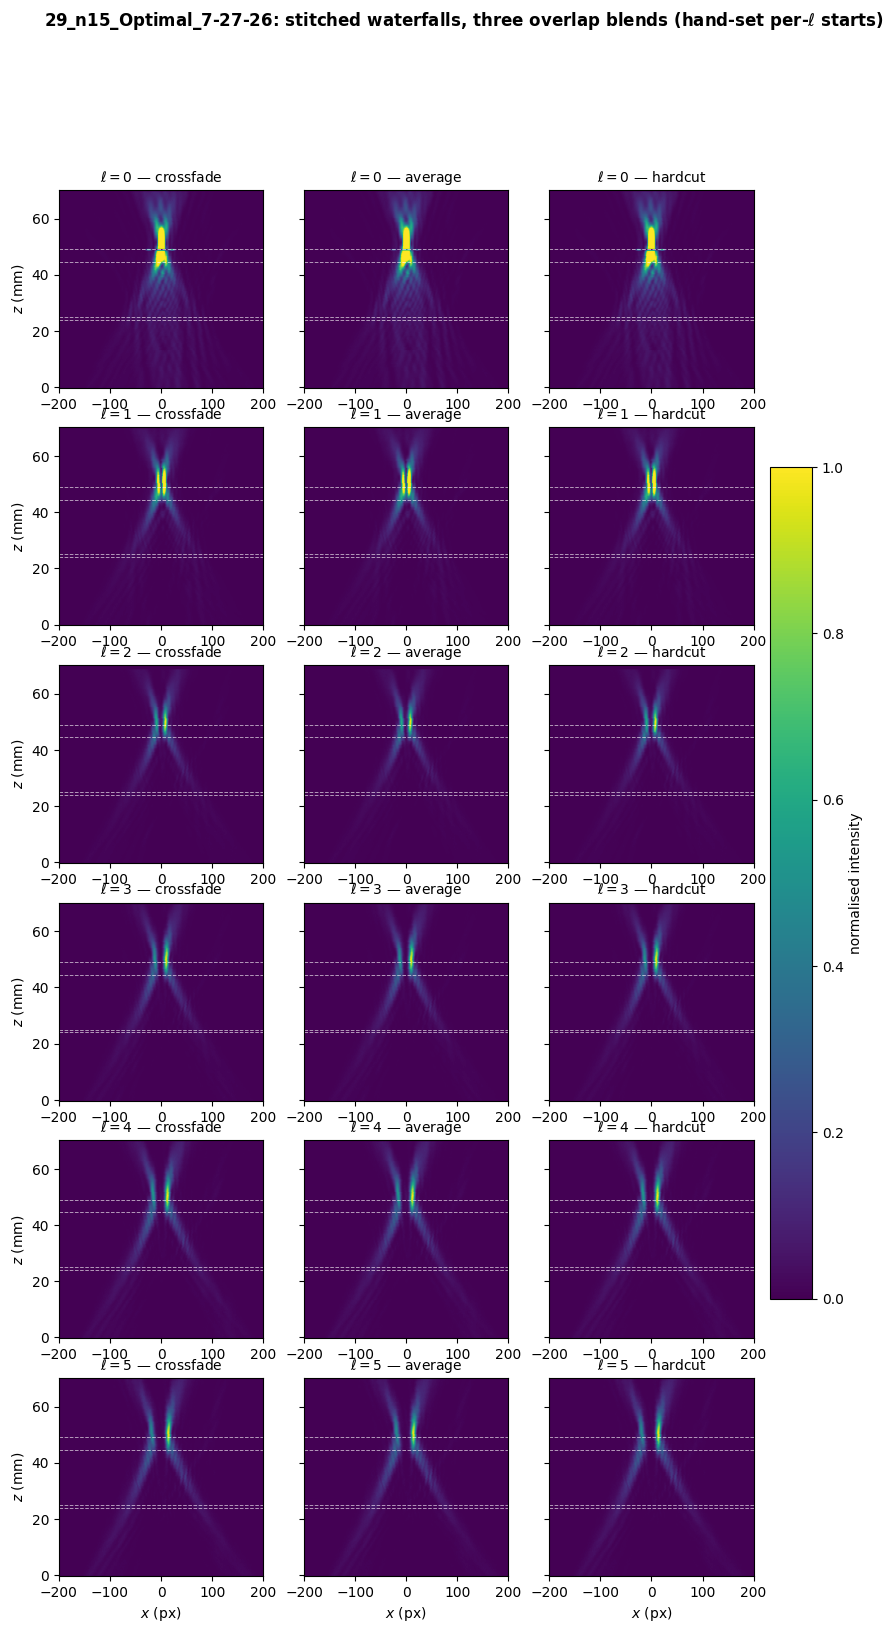

In [10]:
def draw_waterfall(ax, water, s_px, z_mm, title):
    dz = float(np.median(np.diff(z_mm))) if z_mm.size > 1 else STEP_MM
    im = ax.imshow(water, origin="lower", aspect="auto", cmap="viridis", vmin=0, vmax=1,
                   extent=[s_px[0], s_px[-1], z_mm[0] - dz / 2, z_mm[-1] + dz / 2])
    ax.set_xlabel(f"${SLICE_AXIS}$ (px)")
    ax.set_ylabel("$z$ (mm)")
    ax.set_title(title, fontsize=10)
    return im


fig, axes = plt.subplots(len(ELLS), len(BLEND_MODES),
                         figsize=(3.2 * len(BLEND_MODES) + 1.2, 3.0 * len(ELLS)),
                         sharey=True, squeeze=False)
im = None
for r, ell in enumerate(ELLS):
    for c, mode in enumerate(BLEND_MODES):
        st = stitched[ell][mode]
        im = draw_waterfall(axes[r, c], st.waterfall, st.s_px, st.z_mm,
                            f"$\\ell={ell}$ — {mode}")
        for lo, hi in SEAM_BANDS:
            for y in (lo, hi):
                axes[r, c].axhline(y, color="w", ls="--", lw=0.7, alpha=0.6)
        if c > 0:
            axes[r, c].set_ylabel("")
        if r < len(ELLS) - 1:
            axes[r, c].set_xlabel("")

fig.colorbar(im, ax=axes.ravel().tolist(), label="normalised intensity", pad=0.02, shrink=0.6)
fig.suptitle(f"{RUN_LABEL}: stitched waterfalls, three overlap blends (hand-set per-$\\ell$ starts)",
             fontweight="bold")
fig.savefig(OUT_ROOT / "blend_comparison_grid.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

## Final stitched waterfalls (chosen blend)

Set `CHOSEN_BLEND` to whichever read cleanest above. This writes one PNG per $\ell$ under
`outputs/waterfalls_stitched_3seg/l=<n>_<axis>.png` plus the per-run grid.

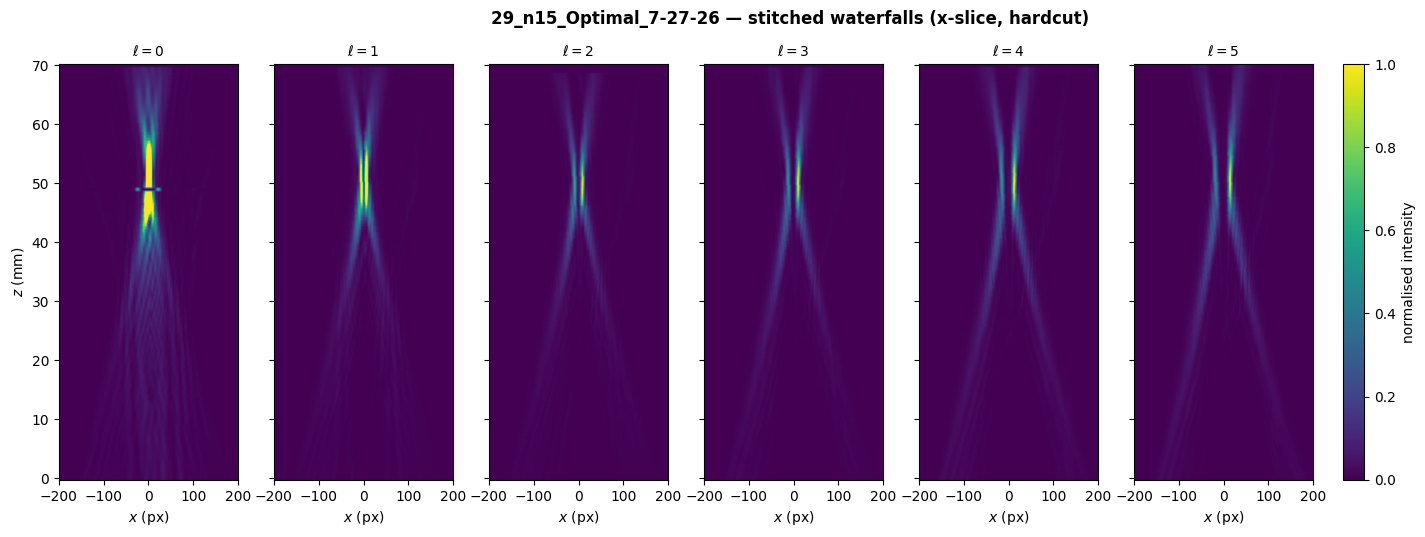

saved per-ell PNGs and the grid to outputs/waterfalls_stitched_3seg


In [11]:
CHOSEN_BLEND = "hardcut"   # <- set to "crossfade" or "average" after eyeballing the grid above
assert CHOSEN_BLEND in BLEND_MODES

group = [stitched[ell][CHOSEN_BLEND] for ell in ELLS]

fig, axes = plt.subplots(1, len(group), figsize=(3.0 * len(group) + 1.5, 5.4),
                         sharey=True, squeeze=False)
im = None
for ax, st in zip(axes[0], group):
    im = draw_waterfall(ax, st.waterfall, st.s_px, st.z_mm, f"$\\ell={st.ell}$")
    ax.set_ylabel("")
axes[0, 0].set_ylabel("$z$ (mm)")
fig.colorbar(im, ax=axes[0].tolist(), label="normalised intensity", pad=0.02)
fig.suptitle(f"{RUN_LABEL} — stitched waterfalls ({SLICE_AXIS}-slice, {CHOSEN_BLEND})",
             fontweight="bold")
fig.savefig(OUT_ROOT / f"{RUN_LABEL}_grid_{SLICE_AXIS}.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

for st in group:
    f, a = plt.subplots(figsize=(5.5, 6.0))
    im = draw_waterfall(a, st.waterfall, st.s_px, st.z_mm,
                        f"{RUN_LABEL}  $\\ell={st.ell}$  ({CHOSEN_BLEND})")
    f.colorbar(im, ax=a, label="normalised intensity")
    f.tight_layout()
    f.savefig(OUT_ROOT / f"l={st.ell}_{SLICE_AXIS}.png", dpi=150)
    plt.close(f)
print(f"saved per-ell PNGs and the grid to {OUT_ROOT.relative_to(REPO_ROOT)}")

## Beam width across the full stitched scan

Transverse RMS beam width of the **stitched** waterfall, per $\ell$, over the whole combined
0 → ~65 mm range — the same feature used to align the segments, now measured on the single
continuous scan so it runs straight through both seams. The seam bands are shaded; smooth
width curves through them confirm the stitch is clean. Focus is where each curve bottoms out.

**Note on $\ell=0$:** it is a Gaussian, not a donut, and its width has no sharp match between
segments, so small steps at the seams are expected and do not affect the donut results.

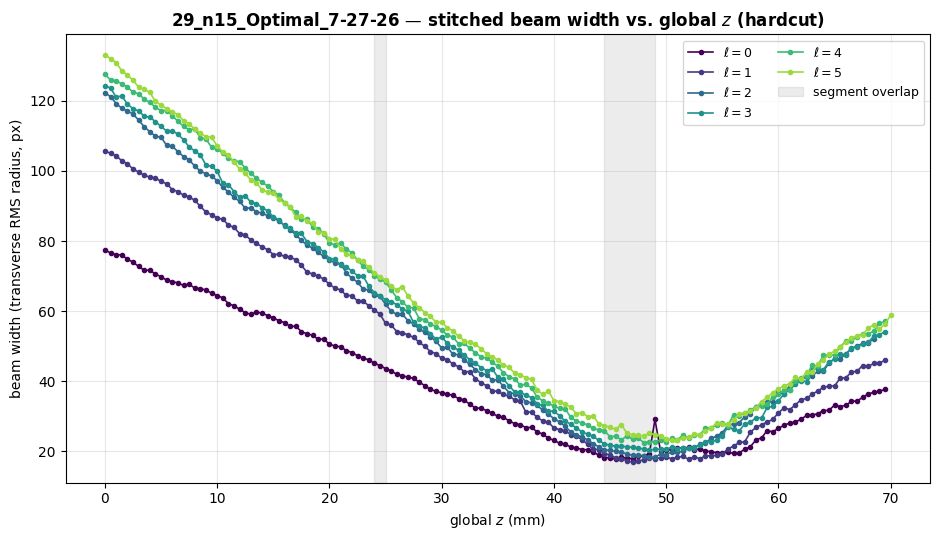

width minimum (focus) per ell:


,ell,z_focus_mm,min_width_px
0,0,45.5,17.72
1,1,47.0,16.84
2,2,49.0,18.32
3,3,48.5,20.35
4,4,48.0,22.49
5,5,50.5,23.09


In [12]:
def stitched_width(st):
    return np.array([_rms_width(row, st.s_px) for row in st.waterfall])


fig, ax = plt.subplots(figsize=(9.5, 5.5))
colours = plt.get_cmap("viridis")(np.linspace(0, 0.85, len(ELLS)))

focus_rows = []
for ell, colour in zip(ELLS, colours):
    st = stitched[ell][CHOSEN_BLEND]
    w = stitched_width(st)
    ax.plot(st.z_mm, w, "o-", ms=3, lw=1.2, color=colour, label=f"$\\ell={ell}$")
    ok = np.isfinite(w) & (st.coverage > 0)
    if ok.any():
        z_focus = float(st.z_mm[ok][np.nanargmin(w[ok])])
        focus_rows.append({"ell": ell, "z_focus_mm": z_focus, "min_width_px": float(np.nanmin(w[ok]))})

for i, (lo, hi) in enumerate(SEAM_BANDS):
    ax.axvspan(lo, hi, color="grey", alpha=0.15,
               label="segment overlap" if i == 0 else None)
ax.set_xlabel("global $z$ (mm)")
ax.set_ylabel("beam width (transverse RMS radius, px)")
ax.set_title(f"{RUN_LABEL} — stitched beam width vs. global $z$ ({CHOSEN_BLEND})",
             fontweight="bold")
ax.legend(ncol=2, fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_ROOT / f"{RUN_LABEL}_stitched_width.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

focus_table = pd.DataFrame(focus_rows).round(2)
print("width minimum (focus) per ell:")
display(focus_table)

## Centroid diagnostic across the stitched scan

The base notebook's centroid figure on the global $z$ grid, with both seams dashed. A
discontinuity at a seam means the two segments' beams sit at different sensor positions —
expected if the stage or camera shifted between acquisitions, harmless for the centred
waterfall, but worth seeing. The bottom panel shows **segment coverage**: how many segments
contribute to each $z$ (1 = single segment, 2 = inside an overlap, 0 = a gap).

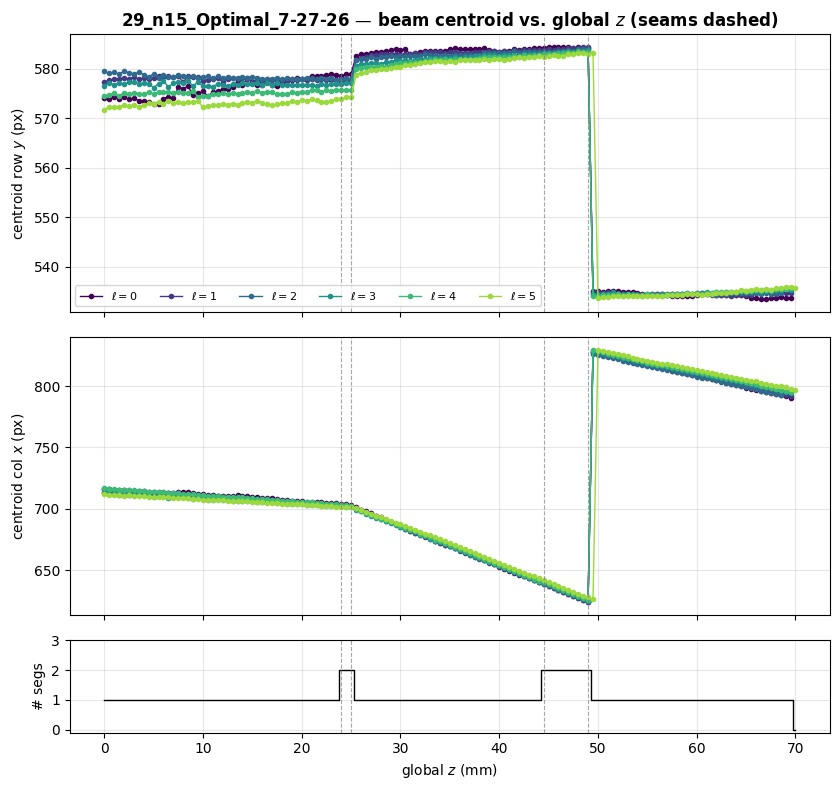

In [13]:
colours = plt.get_cmap("viridis")(np.linspace(0, 0.85, len(ELLS)))
fig, axes = plt.subplots(3, 1, figsize=(8.5, 8), sharex=True,
                         gridspec_kw={"height_ratios": [3, 3, 1]})
for ell, colour in zip(ELLS, colours):
    st = stitched[ell][CHOSEN_BLEND]
    axes[0].plot(st.z_mm, st.centroid_y, "o-", ms=3, lw=1, color=colour, label=f"$\\ell={ell}$")
    axes[1].plot(st.z_mm, st.centroid_x, "o-", ms=3, lw=1, color=colour)

axes[2].step(stitched[ELLS[0]][CHOSEN_BLEND].z_mm,
             stitched[ELLS[0]][CHOSEN_BLEND].coverage, where="mid", color="k", lw=1)
axes[2].set_ylabel("# segs")
axes[2].set_yticks([0, 1, 2, 3])

for ax in axes:
    for lo, hi in SEAM_BANDS:
        for y in (lo, hi):
            ax.axvline(y, color="grey", ls="--", lw=0.8, alpha=0.7)
    ax.grid(alpha=0.3)
axes[0].set_ylabel("centroid row $y$ (px)")
axes[0].set_title(f"{RUN_LABEL} — beam centroid vs. global $z$ (seams dashed)", fontweight="bold")
axes[0].legend(ncol=len(ELLS), fontsize=8)
axes[1].set_ylabel("centroid col $x$ (px)")
axes[2].set_xlabel("global $z$ (mm)")
fig.tight_layout()
fig.savefig(OUT_ROOT / f"{RUN_LABEL}_centroids.png", dpi=150)
plt.show()
plt.close(fig)

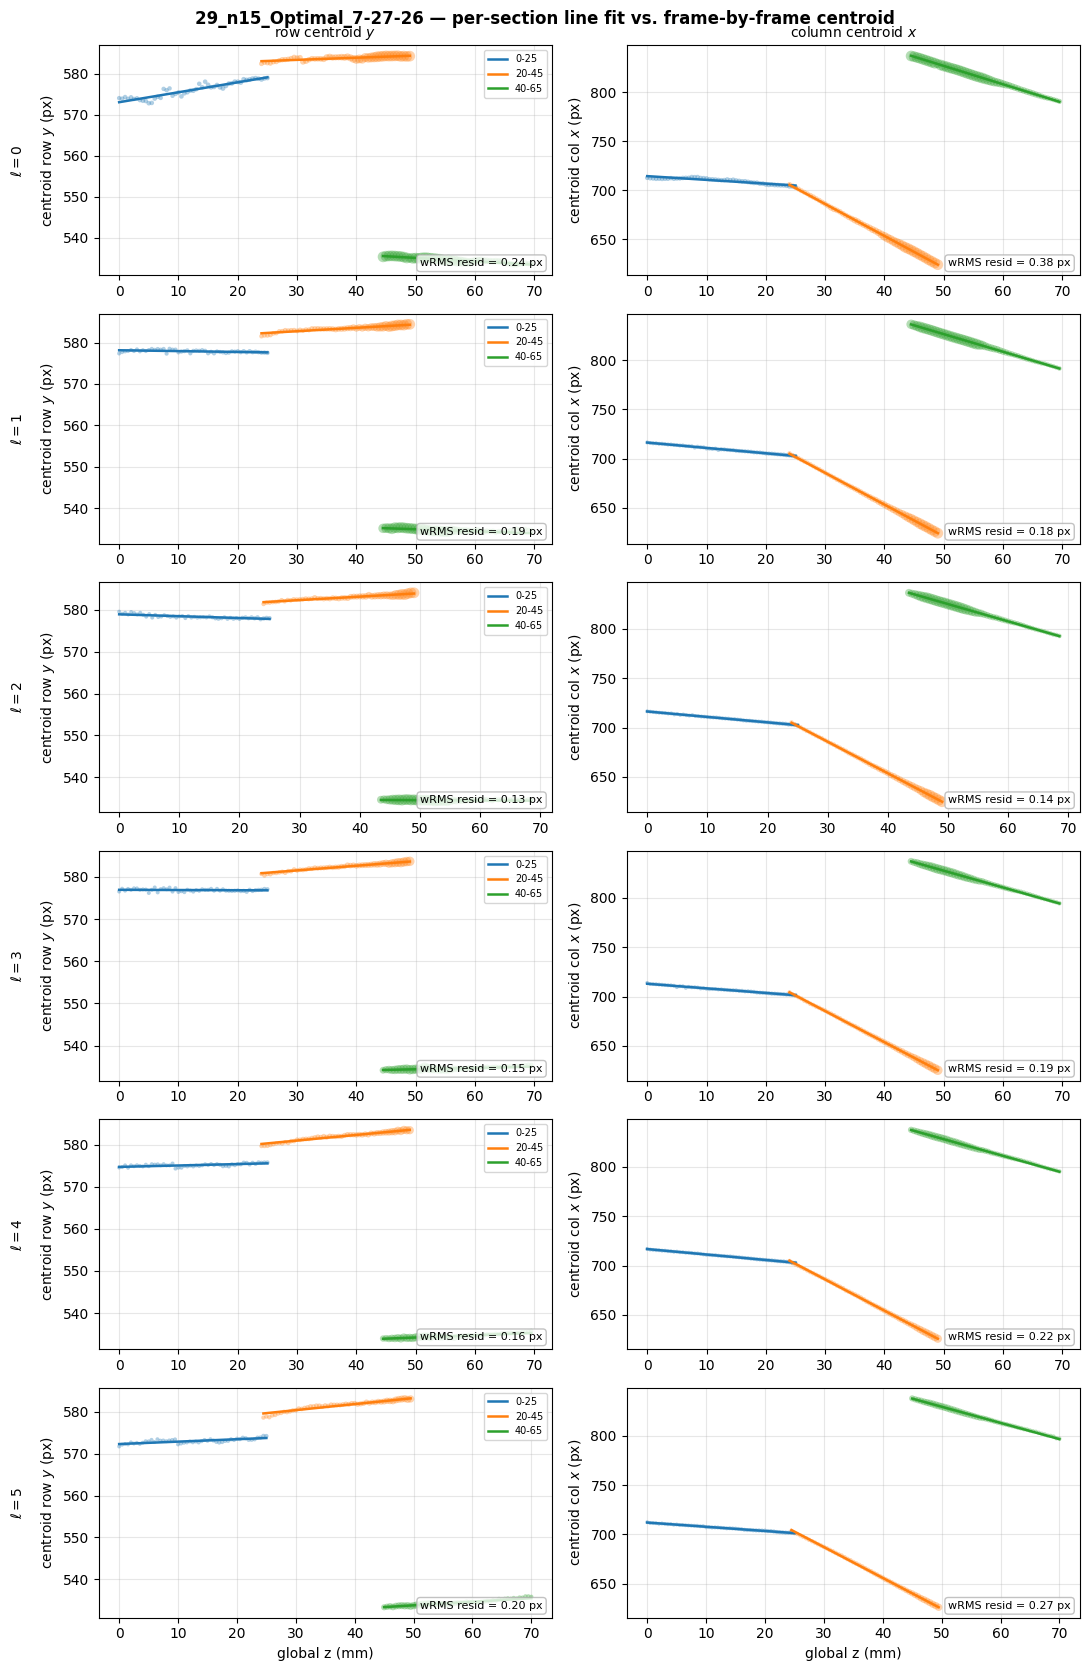

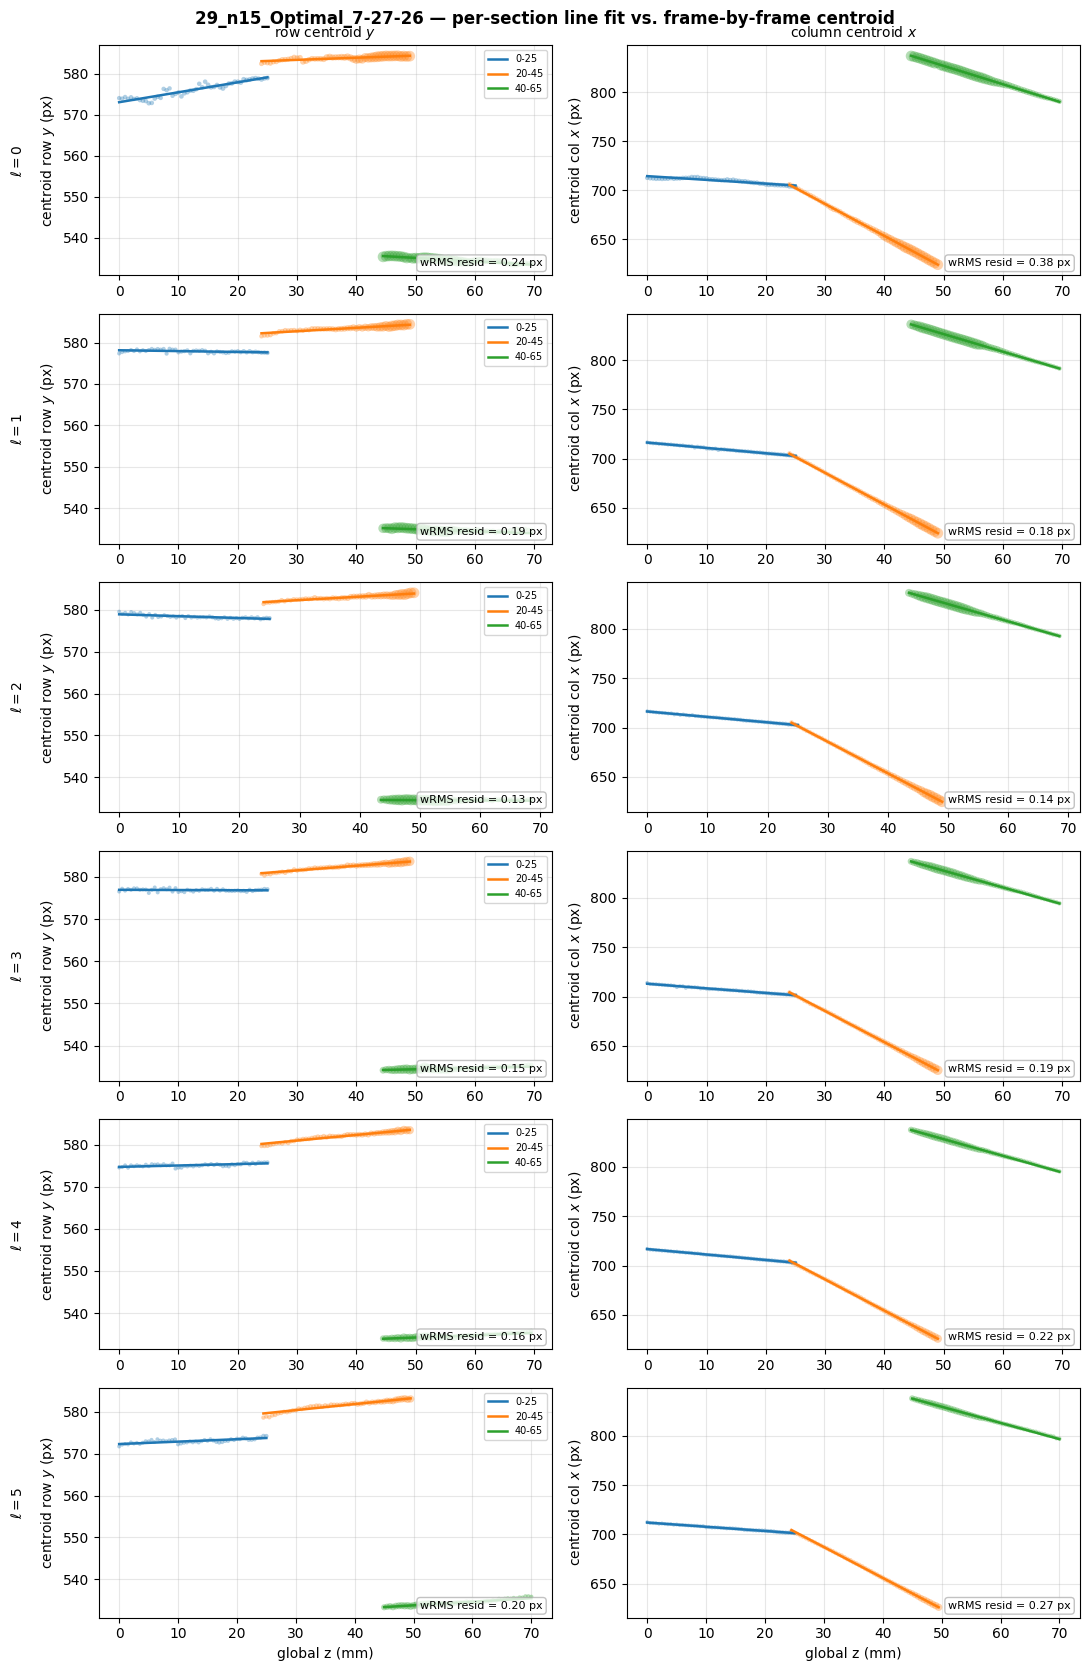

In [14]:
# --- Diagnostic: per-section straight-line fit vs. frame-by-frame centroid ---
# Independent of CENTROID_MODE: each section is given its OWN straight line,
# fit from the raw per-frame centroids, and overlaid -- so the line model can
# be judged even while the waterfalls are built frame-by-frame.  Points are the
# raw per-frame centroids (area ~ brightness weight); the line is the fit.
from centroid_lines import fit_sections_for_plot, plot_centroid_fit

groups = {}
for ell in ELLS:
    if not segments[ell]:
        continue
    raw = {seg: dict(z=global_z(sw, ell), cy=sw.centroid_y_raw,
                     cx=sw.centroid_x_raw, w=sw.centroid_w)
           for seg, sw in segments[ell].items()}
    groups[f"$\\ell={ell}$"] = fit_sections_for_plot(raw)
plot_centroid_fit(
    groups, path=OUT_ROOT / f"{RUN_LABEL}_centroid_fit.png",
    title=f"{RUN_LABEL} — per-section line fit vs. frame-by-frame centroid")


## Summary table

One row per $\ell$ for the chosen blend: the stitched $z$ span, the brightest-frame $z$, and the
hand-set global start applied to each segment.

In [15]:
summary = pd.DataFrame([
    {
        "run": RUN_LABEL,
        "ell": ell,
        "blend": CHOSEN_BLEND,
        "n_frames": stitched[ell][CHOSEN_BLEND].z_mm.size,
        "z_min_mm": stitched[ell][CHOSEN_BLEND].z_mm.min(),
        "z_max_mm": stitched[ell][CHOSEN_BLEND].z_mm.max(),
        "brightest_z_mm": stitched[ell][CHOSEN_BLEND].brightest_z,
        **{f"start_{lbl}_mm": round(STARTS_MM[ell][lbl], 2) for lbl in SEG_LABELS},
    }
    for ell in ELLS
]).round(2)

summary.to_csv(OUT_ROOT / f"{RUN_LABEL}_summary.csv", index=False)
with pd.option_context("display.max_rows", None, "display.width", 200):
    display(summary)
print(f"\nsaved {RUN_LABEL}_summary.csv")

,run,ell,blend,n_frames,z_min_mm,z_max_mm,brightest_z_mm,start_0-25_mm,start_20-45_mm,start_40-65_mm
0,29_n15_Optimal_7-27-26,0,hardcut,141,0.0,70.0,43.5,0.0,24.0,44.5
1,29_n15_Optimal_7-27-26,1,hardcut,141,0.0,70.0,47.0,0.0,24.0,44.5
2,29_n15_Optimal_7-27-26,2,hardcut,141,0.0,70.0,50.0,0.0,24.0,43.5
3,29_n15_Optimal_7-27-26,3,hardcut,141,0.0,70.0,50.0,0.0,24.0,44.5
4,29_n15_Optimal_7-27-26,4,hardcut,141,0.0,70.0,50.5,0.0,24.0,44.5
5,29_n15_Optimal_7-27-26,5,hardcut,141,0.0,70.0,50.0,0.0,24.5,45.0



saved 29_n15_Optimal_7-27-26_summary.csv
